# VIF FILTERING 2
### This notebook is to explore into why the dimensions of the split up datasets don't line up, and to vif filter through the dataframe that has 50 extra features.

In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
counts_sa = pd.read_csv('data/jolts_counts_seasonally_adjusted.csv')
counts_nsa = pd.read_csv('data/jolts_counts_not_seasonally_adjusted.csv')
percents_sa = pd.read_csv('data/jolts_percents_seasonally_adjusted.csv')
percents_nsa = pd.read_csv('data/jolts_percents_not_seasonally_adjusted.csv')

counts_sa.shape, counts_nsa.shape, percents_sa.shape, percents_nsa.shape

((296, 485), (296, 485), (296, 537), (296, 485))

### 50 extra features found!
The 50 extraneous features are in jolts percents seasonally adjusted. Let's see which columns are different...

In [4]:
percents_sa.columns

Index(['Unnamed: 0',
       'Hires: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
       'Job Openings: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
       'Layoffs and Discharges: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
       'Other separations: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
       'Quits: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
       'Total Separations: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
       'UO\tUnemployed persons per job opening ratio: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
       'Hires: Total nonfarm in Alabama - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)',
       'Job Openings: Total nonfarm in Alabama - Rate in Percent, Monthly, Seasonally Adjusted (A

In [5]:
# Remove the "Rate in Percent" part from every column name
percents_sa.columns = [col.replace(' Rate in Percent', '') for col in percents_sa.columns]
percents_sa.columns

Index(['Unnamed: 0',
       'Hires: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Job Openings: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Layoffs and Discharges: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Other separations: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Quits: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Total Separations: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'UO\tUnemployed persons per job opening ratio: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Hires: Total nonfarm in Alabama -, Monthly, Seasonally Adjusted (All size classes)',
       'Job Openings: Total nonfarm in Alabama -, Monthly, Seasonally Adjusted (All size classes)',
       ...
       'Other separations: State and local government education -, Monthly, Seasonally Adjusted (All size classes)

In [6]:
# Use counts_sa as the base dataframe and filter percents_sa to only have the columns that are not in counts_sa
counts_sa.columns

Index(['Unnamed: 0',
       'Hires: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
       'Job Openings: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
       'Layoffs and Discharges: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
       'Other separations: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
       'Quits: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
       'Total Separations: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
       'Hires: Total nonfarm in Alabama - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
       'Job Openings: Total nonfarm in Alabama - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)',
       'Layoffs and Discharges: Total nonfarm in Alabama - Level in Thousands, Monthly, Season

In [7]:
# Remove the "Level in Thoussands" part from every column name
counts_sa.columns = [col.replace(' Level in Thousands', '') for col in counts_sa.columns]
counts_sa.columns

Index(['Unnamed: 0',
       'Hires: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Job Openings: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Layoffs and Discharges: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Other separations: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Quits: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Total Separations: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
       'Hires: Total nonfarm in Alabama -, Monthly, Seasonally Adjusted (All size classes)',
       'Job Openings: Total nonfarm in Alabama -, Monthly, Seasonally Adjusted (All size classes)',
       'Layoffs and Discharges: Total nonfarm in Alabama -, Monthly, Seasonally Adjusted (All size classes)',
       ...
       'Other separations: State and local government education -, Monthly, Seasonally Adjusted (All size classes)',
       '

In [8]:
# Find the differing columns between percents_sa and counts_sa
diff_cols = [col for col in percents_sa.columns if col not in counts_sa.columns]
diff_cols, len(diff_cols)

(['UO\tUnemployed persons per job opening ratio: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)',
  'UO\tUnemployed persons per job opening ratio: Total nonfarm in Alabama -, Monthly, Seasonally Adjusted (All size classes)',
  'UO\tUnemployed persons per job opening ratio: Total nonfarm in Alaska -, Monthly, Seasonally Adjusted (All size classes)',
  'UO\tUnemployed persons per job opening ratio: Total nonfarm in Arizona -, Monthly, Seasonally Adjusted (All size classes)',
  'UO\tUnemployed persons per job opening ratio: Total nonfarm in Arkansas -, Monthly, Seasonally Adjusted (All size classes)',
  'UO\tUnemployed persons per job opening ratio: Total nonfarm in California -, Monthly, Seasonally Adjusted (All size classes)',
  'UO\tUnemployed persons per job opening ratio: Total nonfarm in Colorado -, Monthly, Seasonally Adjusted (All size classes)',
  'UO\tUnemployed persons per job opening ratio: Total nonfarm in Connecticut -, Monthly, Seasonally Adjusted (All siz

### Differing column names found! That's so strange!
Taking a look at all the other dataframe we have, not one of them has a single column within the category "Unemployed persons per job opening ratio", meaning that this dataframe is an exception!

### What should we do about it now?
I think that we should rerun VIF-filtering on this dataframe just to take a look at what the industry, national, regional, and state level totals could possibly contain in terms of columns. Because none of the other dataframe have this category, I want to see if VIF-filtering actually makes a difference on the percents_sa columns that we can get from using VIF.

In [9]:
# Use the drop_redundant_features function to VIF-filter the percents_sa dataframe from the vif_filtering.ipynb file
import statsmodels.api as sm

def drop_redundant_vif_features(df, threshold=5.0):
    """
    Calculates VIF iteratively and removes the feature with the highest VIF 
    until all remaining VIFs are below the specified threshold.
    
    Args:
        df (pd.DataFrame): The DataFrame containing only the numeric features 
                           (no aggregates/totals, no dates/strings).
        threshold (float): The maximum acceptable VIF value.
        
    Returns:
        pd.DataFrame: The DataFrame containing only the selected features.
        pd.DataFrame: A table of the final VIF results.
    """
    # Start with the full, clean DataFrame (only numeric features)
    X = df.copy()
    
    # Drop the 'Unnamed: 0' column if it exists (it was a high-VIF culprit)
    if 'Unnamed: 0' in X.columns:
        X = X.drop(columns=['Unnamed: 0'])

    while True:
        # Add a constant for VIF calculation
        X_vif = sm.add_constant(X)
        
        # Calculate VIFs
        vif_data = pd.DataFrame()
        vif_data["feature"] = X_vif.columns
        vif_data["VIF"] = [
            variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])
        ]
        
        # Sort and exclude the 'const' term
        vif_data = vif_data[vif_data['feature'] != 'const'].sort_values(
            by="VIF", ascending=False
        )
        
        # Check the highest VIF value
        max_vif = vif_data["VIF"].iloc[0] if not vif_data.empty else 0
        feature_to_drop = vif_data["feature"].iloc[0] if not vif_data.empty else None

        if max_vif > threshold:
            # Drop the feature with the highest VIF
            print(f"Dropping '{feature_to_drop}' (VIF: {max_vif:.2f})")
            X = X.drop(columns=[feature_to_drop])
        else:
            # All VIFs are now below the threshold
            print("\nAll VIFs are now below the threshold.")
            return X, vif_data
            
    return X, vif_data # Should be unreachable, but good practice

In [10]:
# --- Scope 1: Granular Scope (State-Level Totals) ---
# Goal: Keep columns that represent TOTAL NONFARM data for individual states (e.g., 'Hires... in Alabama').
# Logic: Must contain a state name AND contain the TOTAL_NONFARM_INDUSTRY phrase.
#        Must NOT contain any REGION_NAMES or the generic NATIONAL TOTAL phrase without 'in'.

STATE_NAMES = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
REGION_NAMES = ['Midwest region', 'Northeast region', 'South region', 'West region']
TOTAL_NONFARM_INDUSTRY = 'Total nonfarm'

df = percents_sa.copy()

def contains_any(text, sub_list):
    return any(sub in text for sub in sub_list)

state_total_columns = [
    col for col in df.columns 
    if contains_any(col, STATE_NAMES) and
       TOTAL_NONFARM_INDUSTRY in col and
       not contains_any(col, REGION_NAMES) and
       ' in ' in col # Ensures it's a state breakdown and not the national total
]

X_state = df[state_total_columns].copy()
final_features_df, final_vifs = drop_redundant_vif_features(X_state)

final_vifs

C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'Hires: Total nonfarm in Alabama -, Monthly, Seasonally Adjusted (All size classes)' (VIF: inf)


C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'Job Openings: Total nonfarm in Alabama -, Monthly, Seasonally Adjusted (All size classes)' (VIF: inf)


C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


...

C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'UO	Unemployed persons per job opening ratio: Total nonfarm in Arizona -, Monthly, Seasonally Adjusted (All size classes)' (VIF: inf)


C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\samee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'Hires: Total nonfarm in Arkansas -, Monthly, Seasonally Adjusted (All size classes)' (VIF: inf)
Dropping 'UO	Unemployed persons per job opening ratio: Total nonfarm in South Carolina -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 164794.71)
Dropping 'Layoffs and Discharges: Total nonfarm in Nevada -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 61175.92)
Dropping 'Layoffs and Discharges: Total nonfarm in Connecticut -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 49410.91)
Dropping 'Total Separations: Total nonfarm in Illinois -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 45079.67)
Dropping 'UO	Unemployed persons per job opening ratio: Total nonfarm in California -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 21189.13)
Dropping 'Total Separations: Total nonfarm in New Jersey -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 14341.98)
Dropping 'Layoffs and Discharges: Total nonfarm in Minnesota -, Monthly, Seasonall

,feature,VIF
17,"Quits: Total nonfarm in Louisiana -, Monthly, ...",4.954685
41,"Quits: Total nonfarm in Ohio -, Monthly, Seaso...",4.934135
20,"Quits: Total nonfarm in Maryland -, Monthly, S...",4.880653
31,"Quits: Total nonfarm in Nevada -, Monthly, Sea...",4.879661
6,Quits: Total nonfarm in District of Columbia -...,4.837066
34,"Quits: Total nonfarm in New Jersey -, Monthly,...",4.707842
57,"Quits: Total nonfarm in Washington -, Monthly,...",4.688044
30,"Hires: Total nonfarm in Nevada -, Monthly, Sea...",4.618282
55,"Quits: Total nonfarm in Virginia -, Monthly, S...",4.577036
35,"Hires: Total nonfarm in New Mexico -, Monthly,...",4.561230


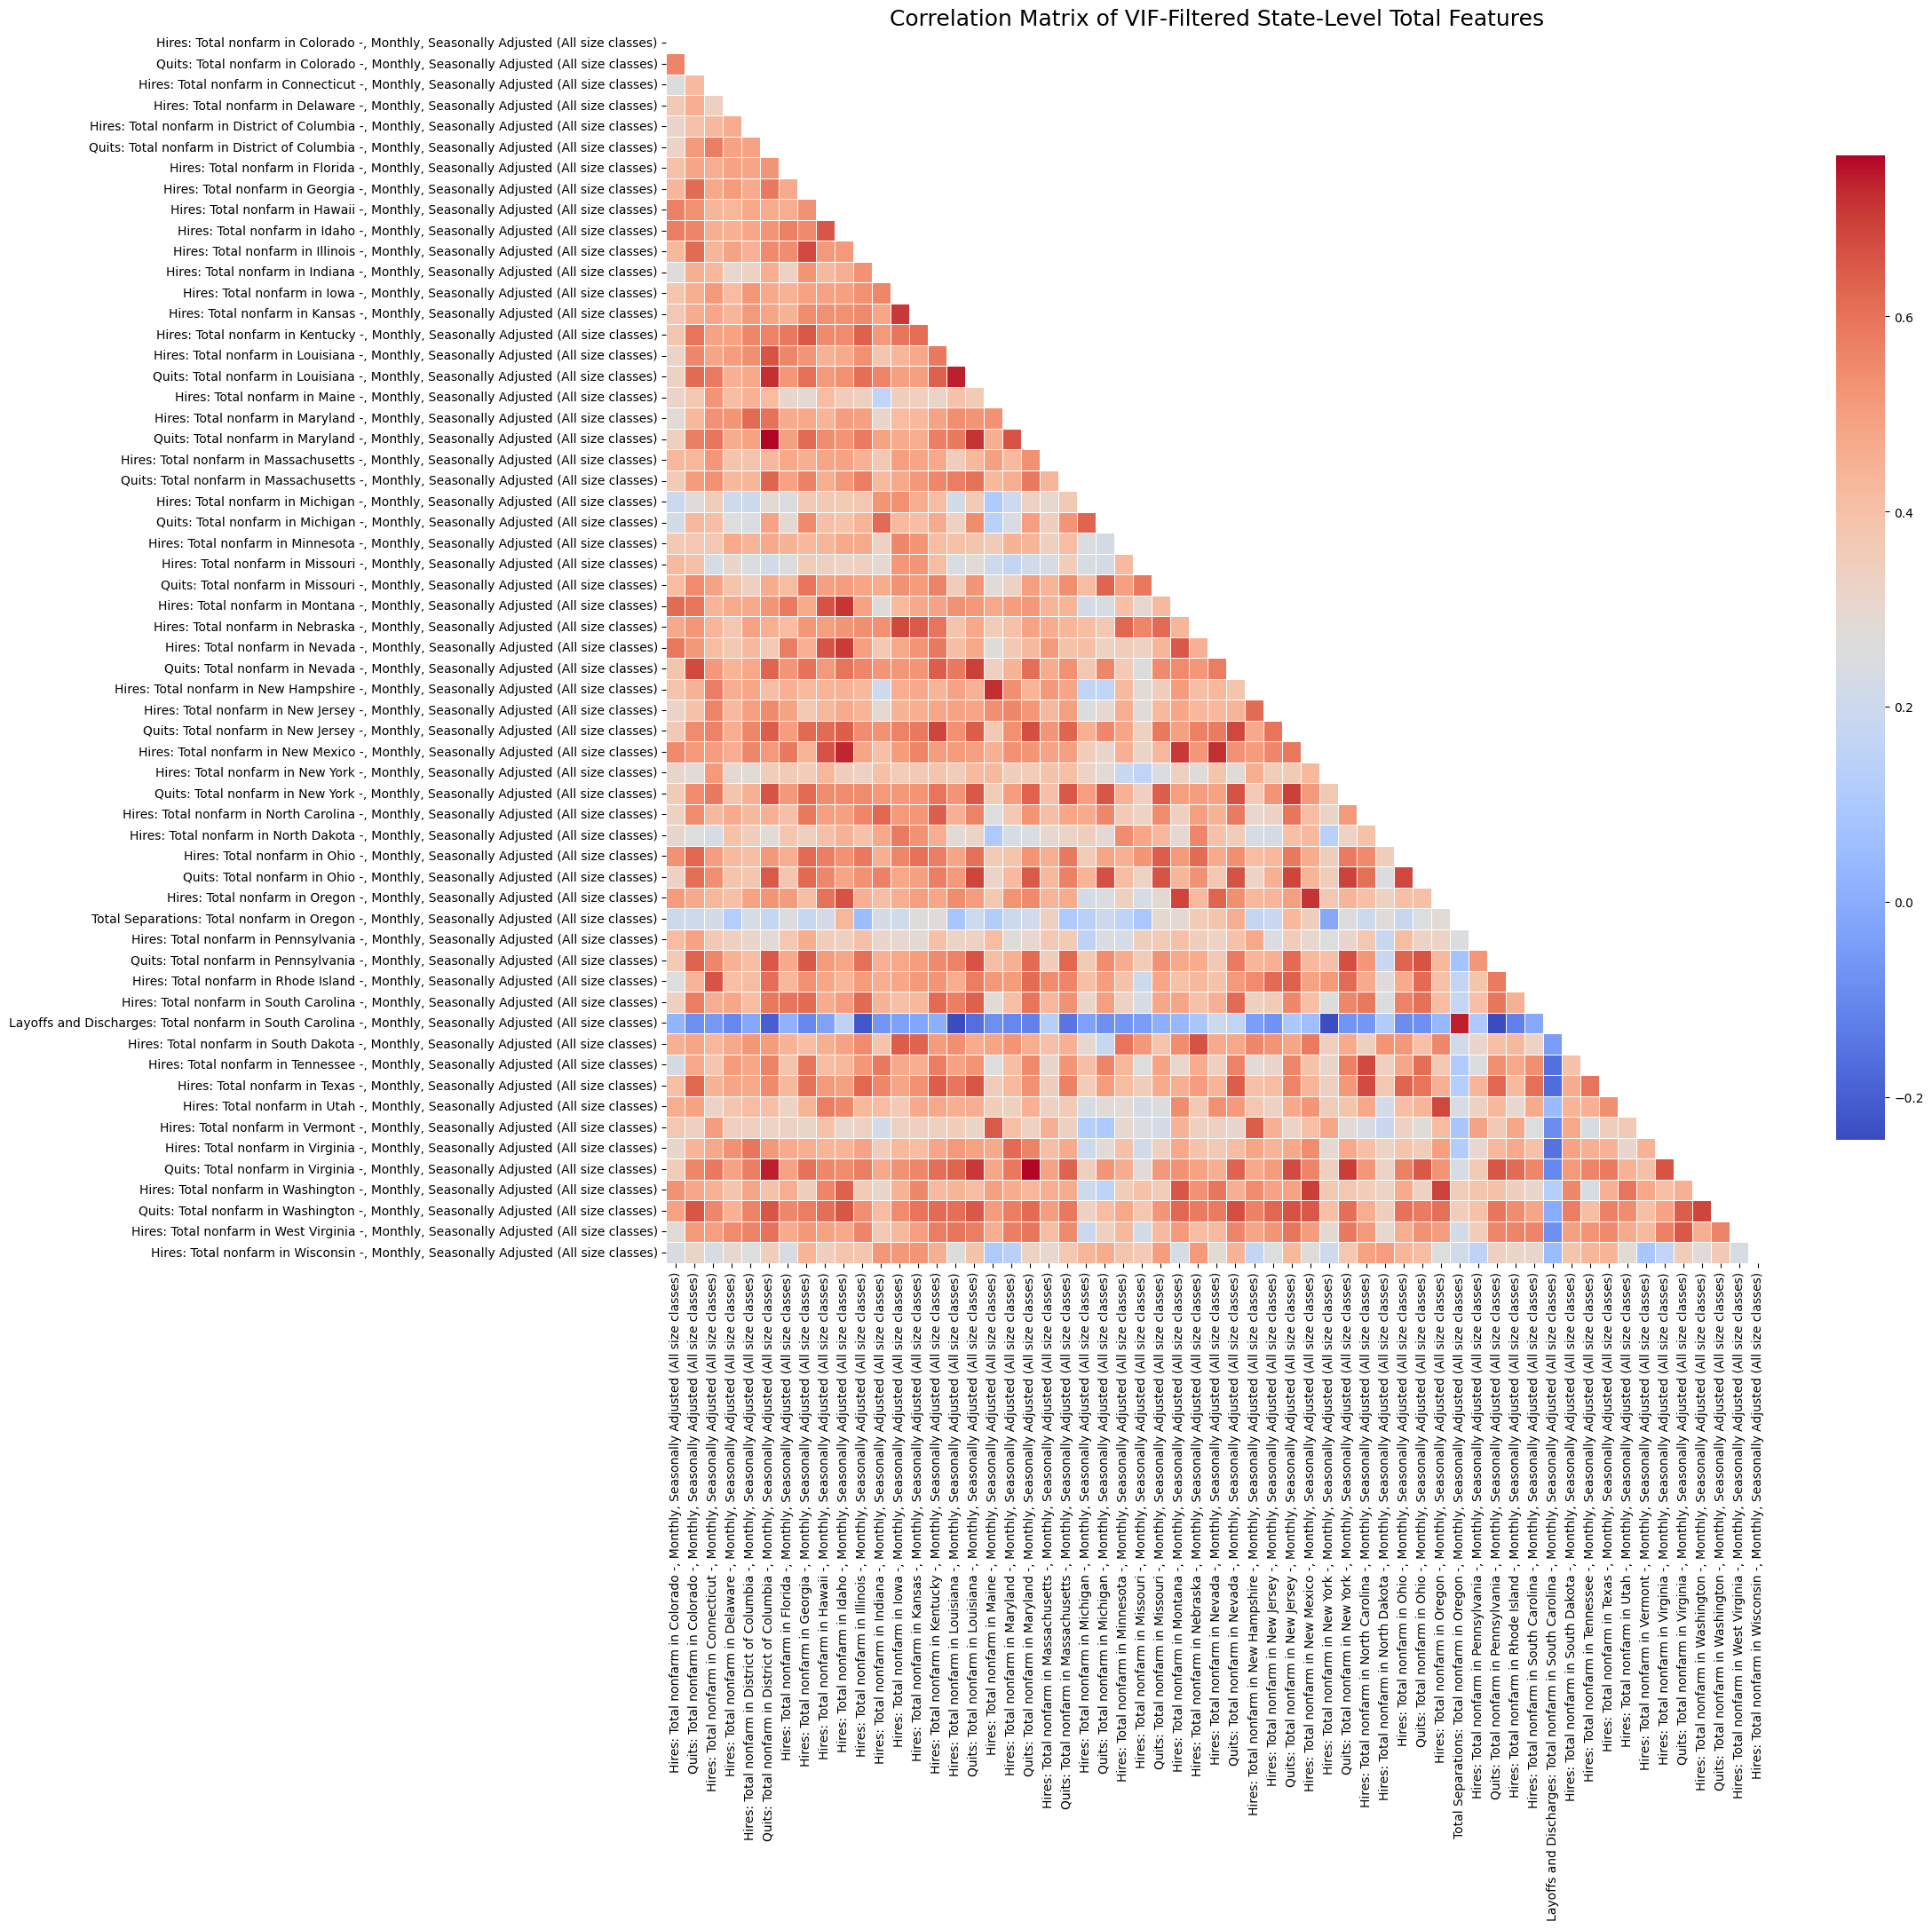

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

### Create correlation matrix similar to above for state-level totals

# Assuming final_features_df is the cleaned DataFrame from the VIF function
# 1. Calculate the correlation matrix

## 1a. Shorten column names for better visualization
final_features_df.columns = final_features_df.columns.str.replace(r' - .*', '', regex=True)

corr_matrix = final_features_df.corr()
# 2. Set up the figure size
plt.figure(figsize=(20, 18))
# 3. Create the heatmap
# Use a diverging color map ('coolwarm') and mask the upper triangle for clarity   
mask = np.triu(corr_matrix) # Helper to mask the upper triangle
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=False, # Set to True if you want numbers, but with many features it's too dense
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Correlation Matrix of VIF-Filtered State-Level Total Features', fontsize=18)
plt.show()

In [13]:
final_features_df.to_csv('data/potential_model_features/percents_sa/state_level_totals_exp.csv', index=False)

In [14]:
# --- Scope 2: Mid-Level Scope (Regional Totals) ---
# Goal: Keep columns that represent TOTAL NONFARM data for the major regions (e.g., 'Hires... in Midwest region').
# Logic: Must contain one of the REGION_NAMES AND contain the TOTAL_NONFARM_INDUSTRY phrase.

regional_total_columns = [
    col for col in df.columns 
    if contains_any(col, REGION_NAMES) and
       TOTAL_NONFARM_INDUSTRY in col
]

X_regional = df[regional_total_columns].copy()
final_features_df_regional, final_vifs_regional = drop_redundant_vif_features(X_regional)

final_vifs_regional

Dropping 'Layoffs and Discharges: Total nonfarm in Northeast region -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 602.66)
Dropping 'Total Separations: Total nonfarm in Midwest region -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 487.74)
Dropping 'Total Separations: Total nonfarm in West region -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 348.22)
Dropping 'Total Separations: Total nonfarm in South region -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 280.45)
Dropping 'Layoffs and Discharges: Total nonfarm in Midwest region -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 62.11)
Dropping 'Job Openings: Total nonfarm in South region -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 52.74)
Dropping 'Job Openings: Total nonfarm in Midwest region -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 41.90)
Dropping 'Total Separations: Total nonfarm in Northeast region -, Monthly, Seasonally Adjusted (All size classes)' (VIF

,feature,VIF
1,"Hires: Total nonfarm in Midwest region -, Mont...",3.803245
8,"Hires: Total nonfarm in West region -, Monthly...",3.036896
4,Job Openings: Total nonfarm in Northeast regio...,2.500822
3,"Hires: Total nonfarm in Northeast region -, Mo...",2.298092
9,Other separations: Total nonfarm in West regio...,1.320360
7,Other separations: Total nonfarm in South regi...,1.303919
5,Other separations: Total nonfarm in Northeast ...,1.257739
2,Other separations: Total nonfarm in Midwest re...,1.246450
6,Layoffs and Discharges: Total nonfarm in South...,1.172773


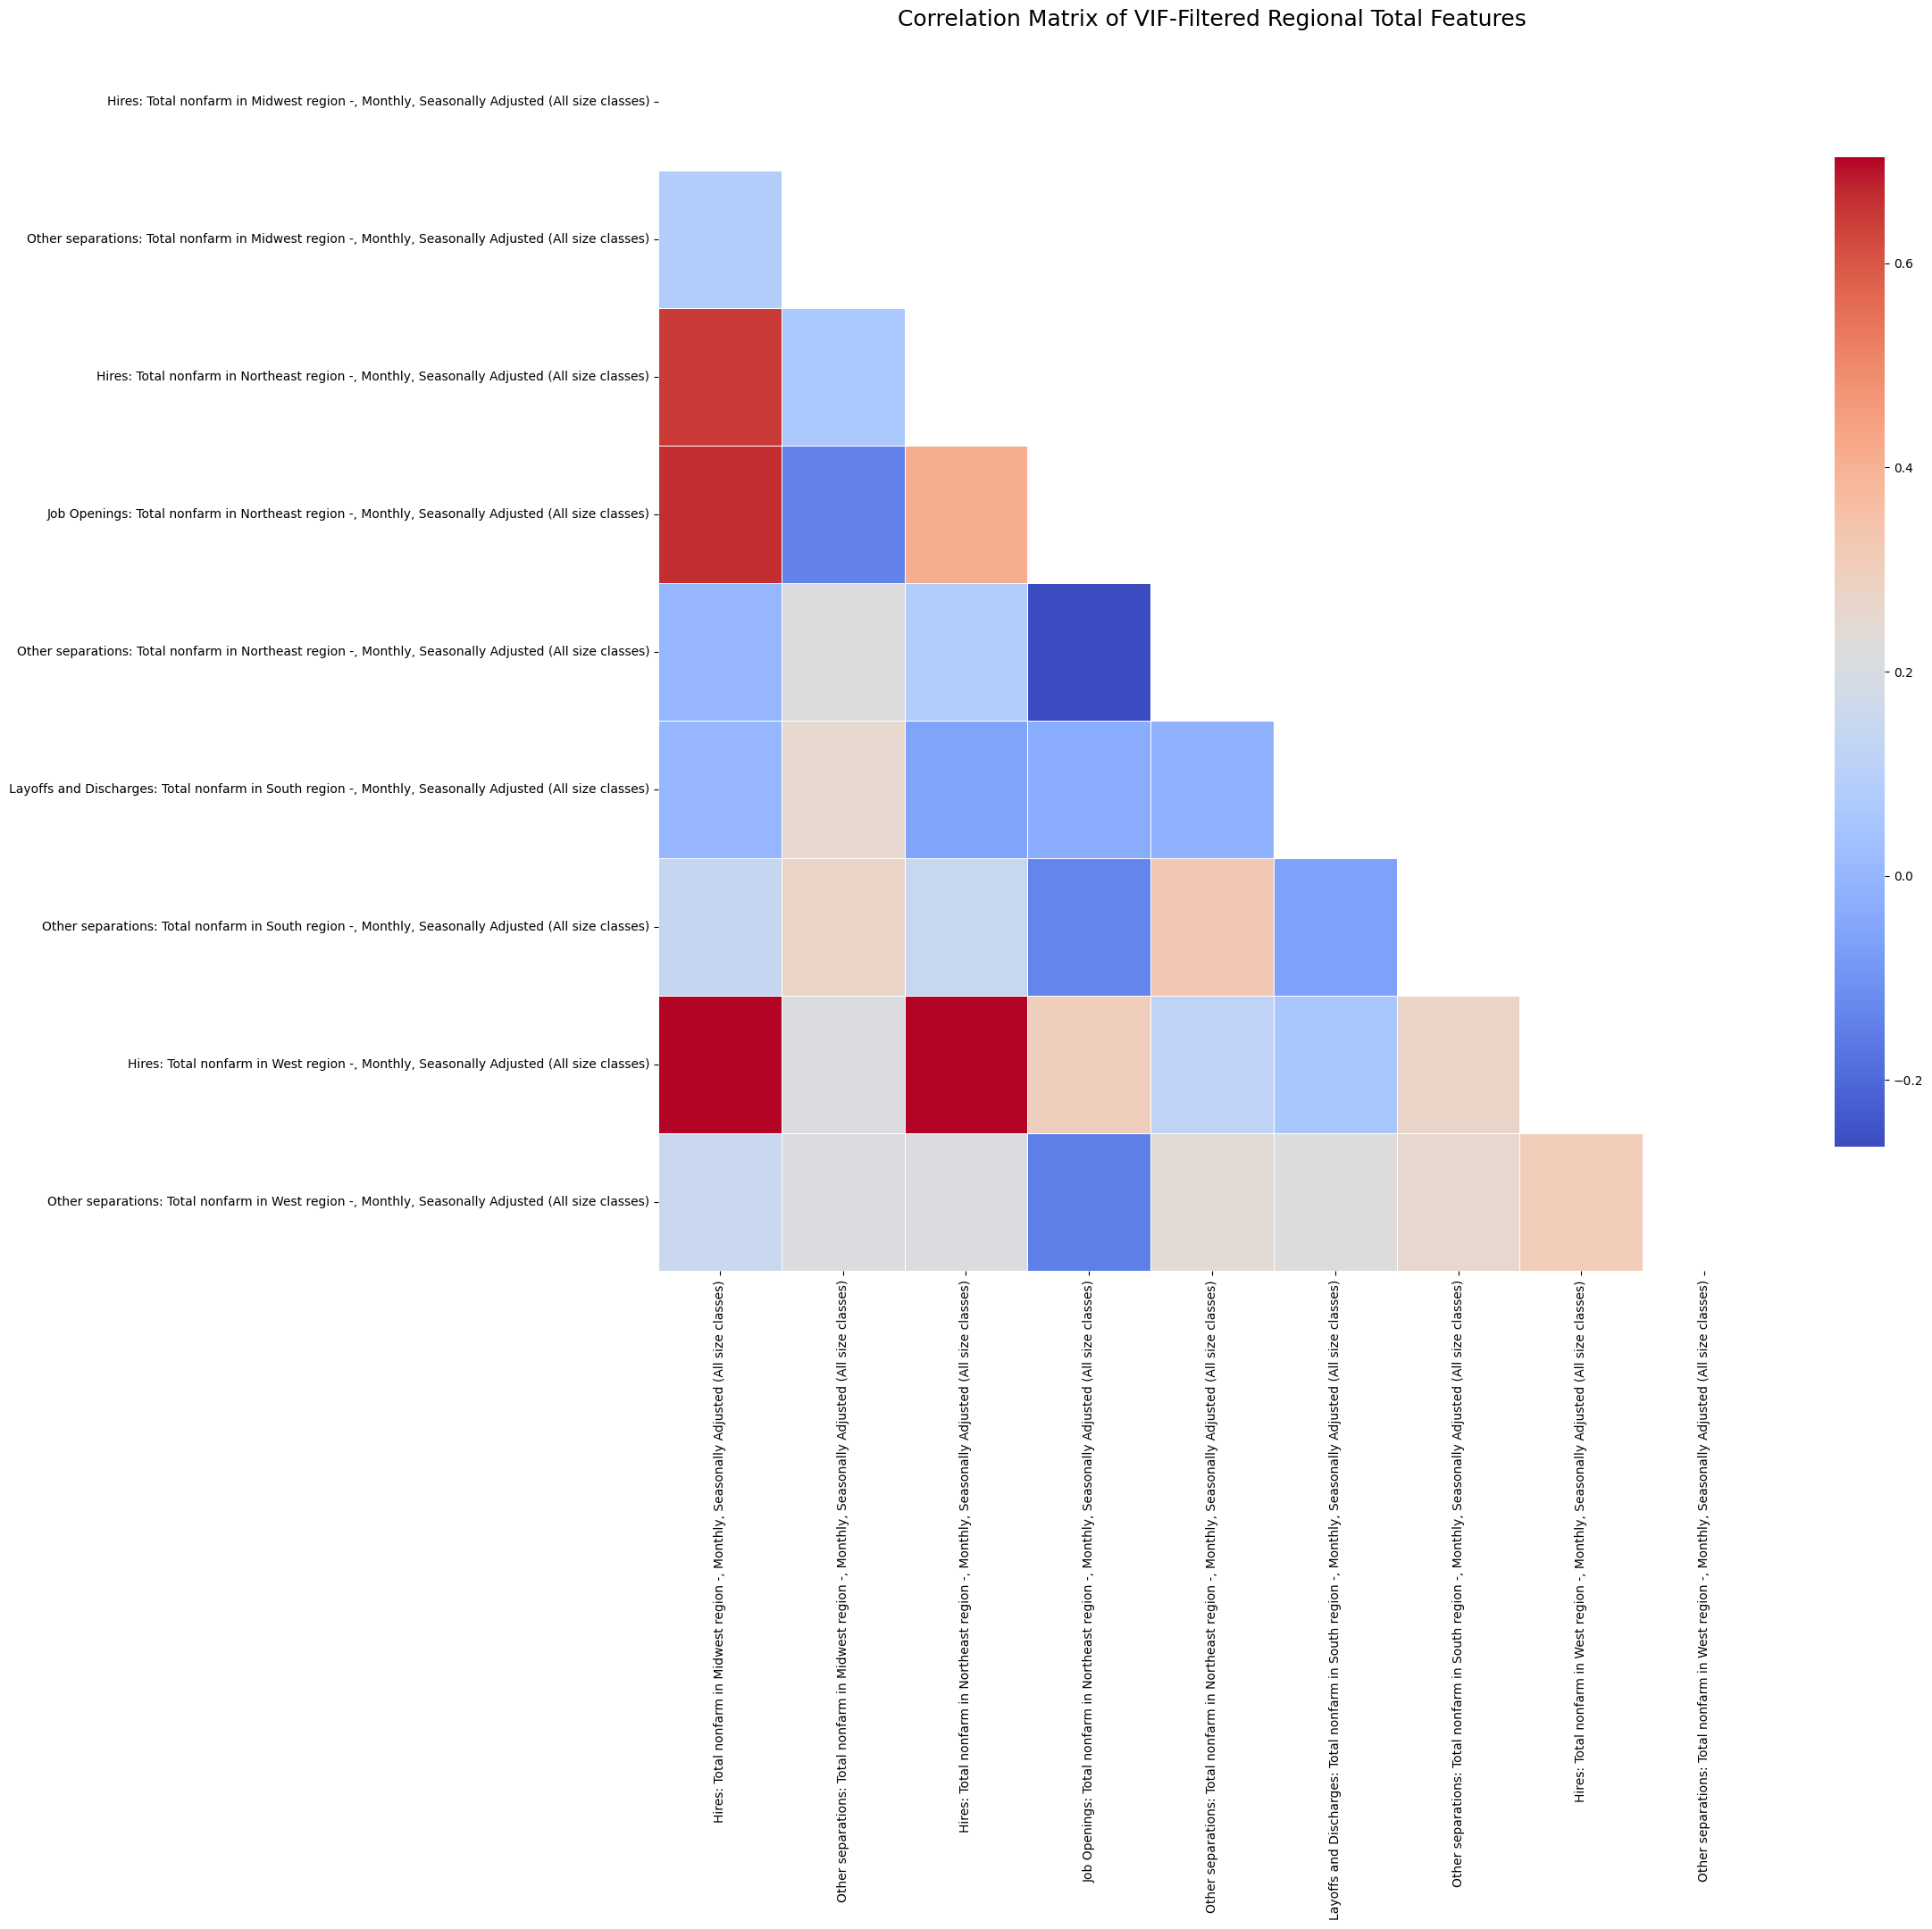

In [15]:
### Create correlation matrix similar to above for regional-level totals
# Assuming final_features_df_regional is the cleaned DataFrame from the VIF function
# 1. Calculate the correlation matrix
## 1a. Shorten column names for better visualization
final_features_df_regional.columns = final_features_df_regional.columns.str.replace(r' - .*', '', regex=True)
corr_matrix = final_features_df_regional.corr()
# 2. Set up the figure size
plt.figure(figsize=(20, 18))
# 3. Create the heatmap
# Use a diverging color map ('coolwarm') and mask the upper triangle for clarity   
mask = np.triu(corr_matrix) # Helper to mask the upper triangle
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=False, # Set to True if you want numbers, but with many features it's too dense
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Correlation Matrix of VIF-Filtered Regional Total Features', fontsize=18)
plt.show()

In [16]:
final_features_df_regional.to_csv('data/potential_model_features/percents_sa/regional_level_totals_exp.csv', index=False)

In [17]:
# --- Scope 3: Broad Scope (National Totals) ---
# Goal: Keep columns that represent the absolute National Total (e.g., 'Hires: Total nonfarm - Level in Thousands...').
# Logic: Must contain TOTAL_NONFARM_INDUSTRY AND NOT contain any specific state or region name.

national_total_columns = [
    col for col in df.columns 
    if 'Total' in col and
       not contains_any(col, STATE_NAMES) and
         not contains_any(col, REGION_NAMES)
]

X_national = df[national_total_columns].copy()
final_features_df_national, final_vifs_national = drop_redundant_vif_features(X_national)

Dropping 'Total Separations: Leisure and hospitality -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 14828.82)
Dropping 'Job Openings: Total private -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 2306.24)
Dropping 'Total Separations: Total private -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 2059.12)
Dropping 'Total Separations: Total private -, Monthly, Seasonally Adjusted (10 to 49 employees)' (VIF: 1961.44)
Dropping 'Layoffs and Discharges: Total private -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 1855.38)
Dropping 'Total Separations: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 1433.72)
Dropping 'Layoffs and Discharges: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 1244.98)
Dropping 'Job Openings: Total nonfarm -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 1047.33)
Dropping 'Total Separations: Total private -, Monthly, Seasonally Adjusted (50 to 249 employees)' (VIF: 899

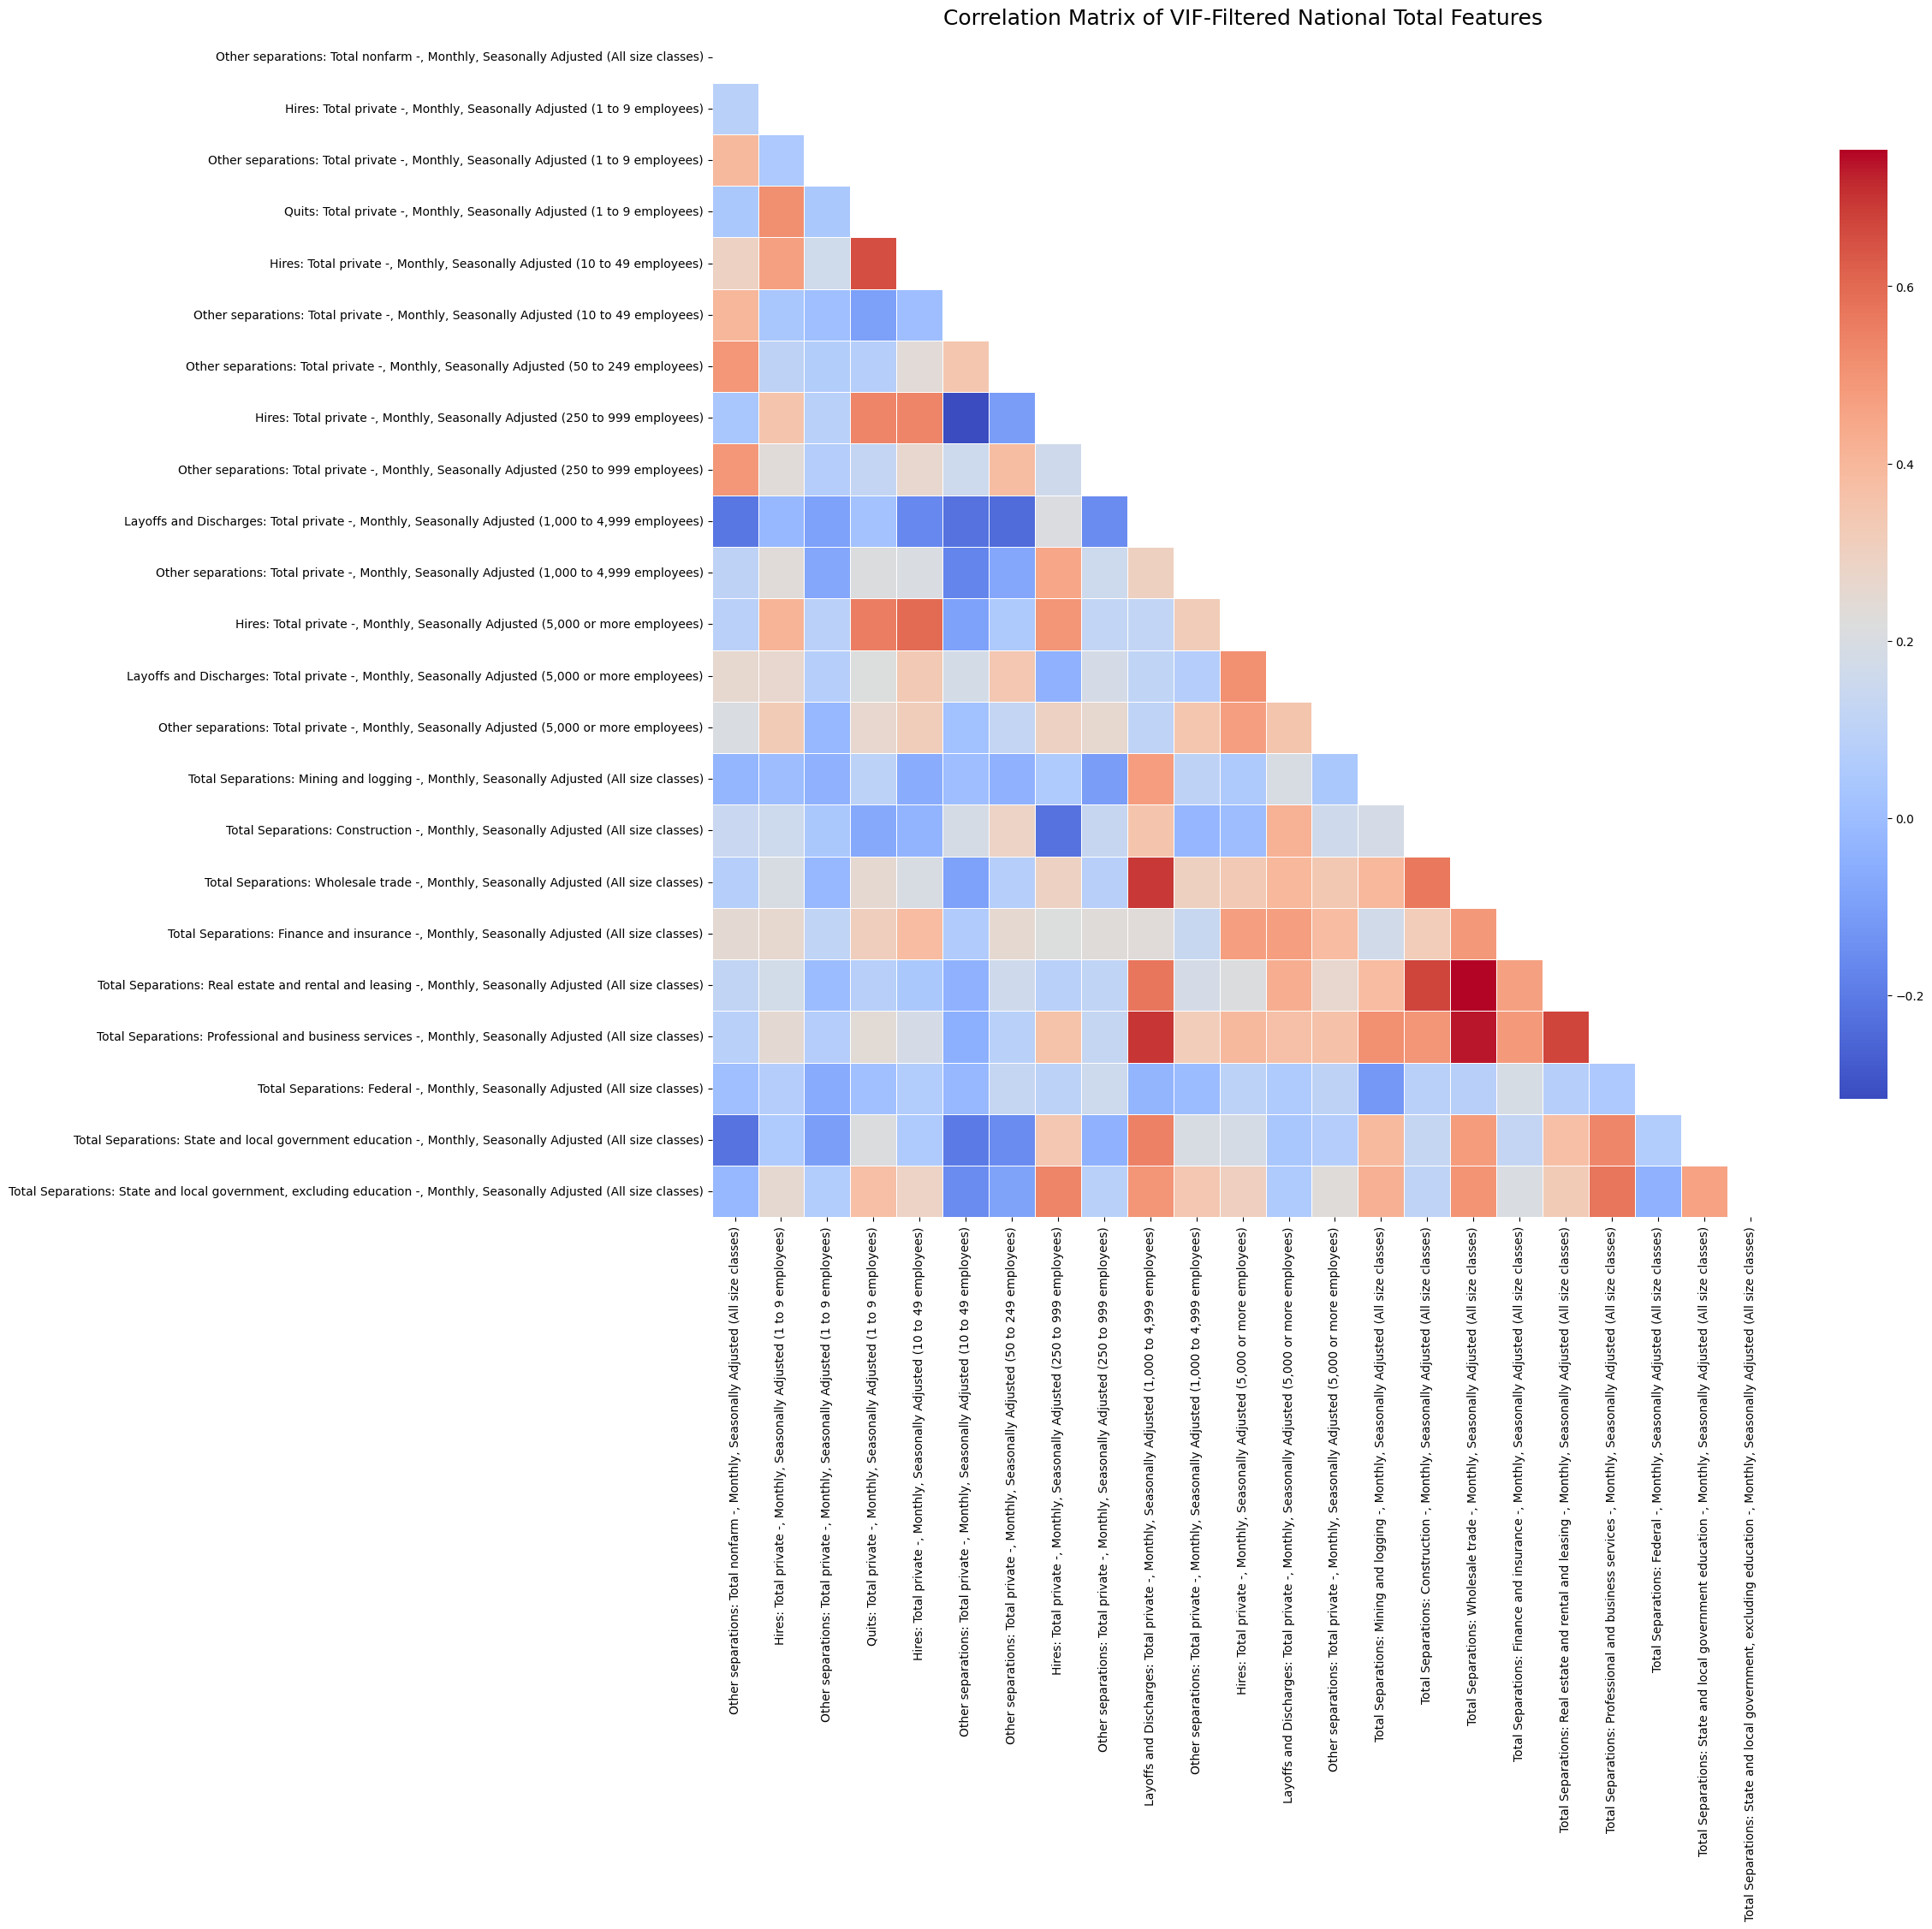

In [18]:
### Plot the correlation matrix for national totals
# Assuming final_features_df_national is the cleaned DataFrame from the VIF function
# 1. Calculate the correlation matrix
## 1a. Shorten column names for better visualization
#final_features_df_national.columns = final_features_df_national.columns.str.replace(r' - .*', '', regex=True)
corr_matrix = final_features_df_national.corr()
# 2. Set up the figure size
plt.figure(figsize=(20, 18))
# 3. Create the heatmap
# Use a diverging color map ('coolwarm') and mask the upper triangle for clarity   
mask = np.triu(corr_matrix) # Helper to mask the upper triangle
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=False, # Set to True if you want numbers, but with many features it's too dense
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Correlation Matrix of VIF-Filtered National Total Features', fontsize=18)
plt.show()

In [19]:
final_features_df_national.to_csv('data/potential_model_features/percents_sa/national_level_totals_exp.csv', index=False)

In [31]:
industry_total_columns = [
    col for col in df.columns 
    if not "Total" in col
]

X_industry = df[industry_total_columns].copy().drop(columns=['date', 'Unnamed: 0'])
final_features_df_industry, final_vifs_industry = drop_redundant_vif_features(X_industry)

final_vifs_industry

Dropping 'Layoffs and Discharges: Leisure and hospitality -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 21031.48)
Dropping 'Job Openings: Leisure and hospitality -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 4589.43)
Dropping 'Job Openings: Private education and health services -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 3375.11)
Dropping 'Job Openings: Manufacturing -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 2077.87)
Dropping 'Job Openings: Trade, transportation, and utilities -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 1881.43)
Dropping 'Job Openings: Government -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 1580.30)
Dropping 'Job Openings: Financial activities -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 1507.05)
Dropping 'Job Openings: State and local -, Monthly, Seasonally Adjusted (All size classes)' (VIF: 1176.48)
Dropping 'Layoffs and Discharges: Trade, transportation, and utilities -, Mo

,feature,VIF
18,"Job Openings: Information -, Monthly, Seasonal...",4.617237
14,"Quits: Wholesale trade -, Monthly, Seasonally ...",4.506810
9,"Hires: Durable goods manufacturing -, Monthly,...",4.504813
19,"Layoffs and Discharges: Information -, Monthly...",4.488963
54,"Quits: State and local government education -,...",4.370199
36,Other separations: Health care and social assi...,4.185767
32,Other separations: Private education and healt...,4.183461
55,"Hires: State and local government, excluding e...",4.056305
27,Job Openings: Real estate and rental and leasi...,3.951394
12,"Hires: Wholesale trade -, Monthly, Seasonally ...",3.882873


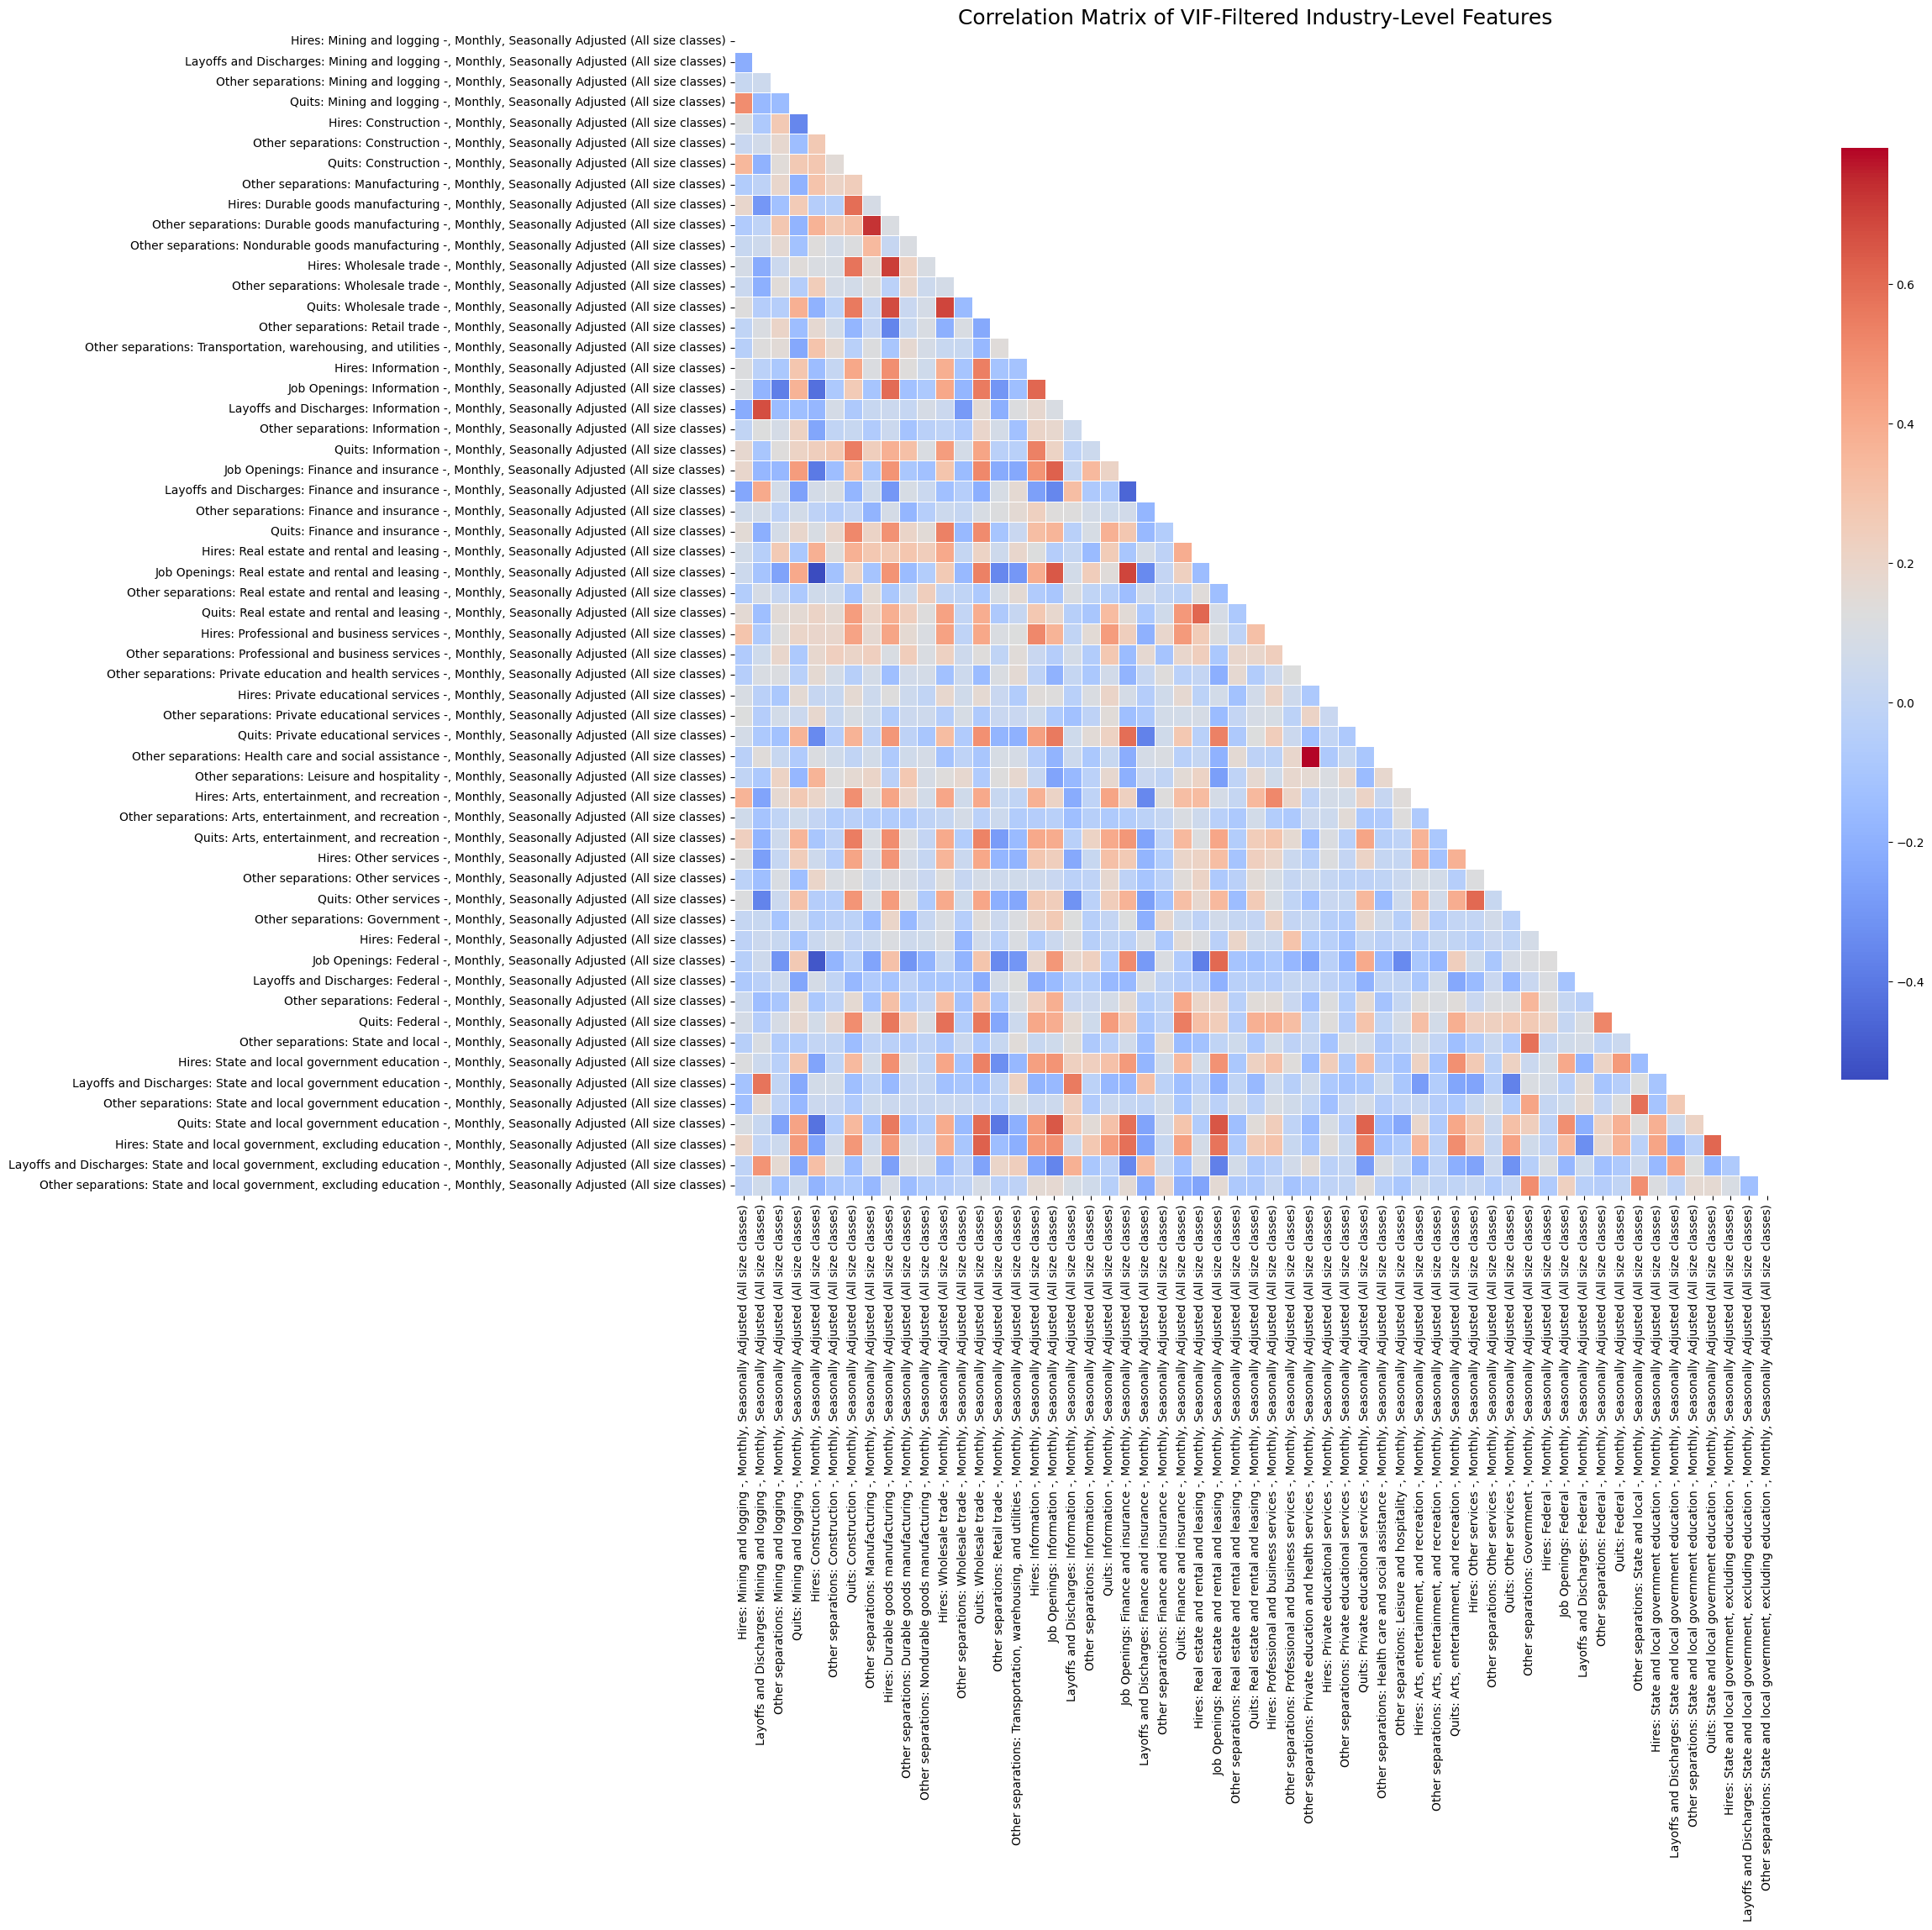

In [32]:
### Plot correlation matrix similar to above for national-level totals
# Assuming final_features_df_industry is the cleaned DataFrame from the VIF function
# 1. Calculate the correlation matrix
## 1a. Shorten column names for better visualization
final_features_df_industry.columns = final_features_df_industry.columns.str.replace(r' - .*', '', regex=True)
corr_matrix = final_features_df_industry.corr()
# 2. Set up the figure size
plt.figure(figsize=(20, 18))
# 3. Create the heatmap
# Use a diverging color map ('coolwarm') and mask the upper triangle for clarity
mask = np.triu(corr_matrix) # Helper to mask the upper triangle
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=False, # Set to True if you want numbers, but with many features it's too dense
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)      
plt.title('Correlation Matrix of VIF-Filtered Industry-Level Features', fontsize=18)
plt.show()

In [33]:
final_features_df_industry.to_csv('data/potential_model_features/percents_sa/industry_level_totals_exp.csv', index=False)